In [ ]:
!pip install yt-dlp pydub noisereduce soundfile librosa pysrt -q
!pip install silero-vad -q
!apt-get install -y ffmpeg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 45.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

VIDEO_PATH = "/content/drive/MyDrive/minibodo/"
print(os.listdir(VIDEO_PATH))

Mounted at /content/drive
['bodo_podcast.mp4', 'bodo_movie.mp4']


In [ ]:
import subprocess
import os

AUDIO_PATH = "/content/drive/MyDrive/minibodo/audio_files"
os.makedirs(AUDIO_PATH, exist_ok=True)

# Specify which audio stream to extract per video (0-indexed)
# For dual-audio video, set the stream index of the Assamese track
# For single-audio videos, stream 0 is fine

AUDIO_STREAM_MAP = {}

video_files = [f for f in os.listdir(VIDEO_PATH)
               if f.endswith(('.mp4', '.mkv', '.avi'))]

for video in video_files:
    input_path  = os.path.join(VIDEO_PATH, video)
    output_name = os.path.splitext(video)[0] + ".wav"
    output_path = os.path.join(AUDIO_PATH, output_name)

    if os.path.exists(output_path):
        print(f"Already exists, skipping: {output_name}")
        continue

    # Pick stream index: use mapping if defined, else default to 0
    stream_index = AUDIO_STREAM_MAP.get(video, 0)

    cmd = [
        "ffmpeg", "-i", input_path,
        "-map", f"0:a:{stream_index}",  # ← picks specific audio stream
        "-ac", "1",       # mono
        "-ar", "16000",   # 16kHz
        "-vn",            # no video
        output_path, "-y"
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print(f"Extracted (stream a:{stream_index}): {output_name}")

print("\nAll audio files:")
print(os.listdir(AUDIO_PATH))

Extracted (stream a:0): bodo_podcast.wav
Extracted (stream a:0): bodo_movie.wav

All audio files:
['bodo_podcast.wav', 'bodo_movie.wav']


In [ ]:
import librosa
import numpy as np

audio_files = [f for f in os.listdir(AUDIO_PATH) if f.endswith('.wav')]

print(f"Total audio files: {len(audio_files)}\n")

for fname in audio_files:
    fpath = os.path.join(AUDIO_PATH, fname)
    y, sr = librosa.load(fpath, sr=16000)
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"{fname}")
    print(f"  Duration : {duration/60:.1f} minutes")
    print(f"  SR       : {sr} Hz")
    print(f"  Samples  : {len(y)}")

Total audio files: 2

bodo_podcast.wav
  Duration : 111.6 minutes
  SR       : 16000 Hz
  Samples  : 107175509
bodo_movie.wav
  Duration : 152.6 minutes
  SR       : 16000 Hz
  Samples  : 146481877


In [ ]:
import torch
import torchaudio
import soundfile as sf
import os



# Load silero VAD model
vad_model, vad_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False
)

(get_speech_timestamps,
 save_audio,
 read_audio,
 VADIterator,
 collect_chunks) = vad_utils

def segment_audio_vad(audio_path, output_dir, filename_prefix,
                       min_dur=1.5, max_dur=8.0):
    """
    Segments a long audio file into utterances using VAD.
    Keeps segments between min_dur and max_dur seconds.
    """
    wav = read_audio(audio_path, sampling_rate=16000)

    speech_timestamps = get_speech_timestamps(
        wav, vad_model,
        sampling_rate=16000,
        threshold=0.5,           # confidence threshold
        min_speech_duration_ms=500,
        min_silence_duration_ms=300,
        speech_pad_ms=100        # add 100ms padding around speech
    )

    print(f"Found {len(speech_timestamps)} speech segments")

    saved, skipped = 0, 0
    segment_info = []

    for i, ts in enumerate(speech_timestamps):
        start  = ts['start']
        end    = ts['end']
        duration = (end - start) / 16000

        if not (min_dur <= duration <= max_dur):
            skipped += 1
            continue

        segment = wav[start:end]
        fname   = f"{filename_prefix}_seg{i:04d}.wav"
        fpath   = os.path.join(output_dir, fname)
        save_audio(fpath, segment, sampling_rate=16000)

        segment_info.append({
            'filename' : fpath,
            'duration' : round(duration, 2),
            'start_sample': start,
            'end_sample'  : end,
        })
        saved += 1

    print(f"Saved: {saved} | Skipped (wrong duration): {skipped}")
    return segment_info

SEGMENT_PATH = "/content/drive/MyDrive/minibodo/segmented_audio"
os.makedirs(SEGMENT_PATH, exist_ok=True)
# Run VAD on all audio files
all_segments = []

for fname in audio_files:
    fpath  = os.path.join(AUDIO_PATH, fname)
    prefix = os.path.splitext(fname)[0][:20]  # short prefix
    print(f"\nProcessing: {fname}")
    segs = segment_audio_vad(fpath, SEGMENT_PATH, prefix)
    all_segments.extend(segs)

print(f"\nTotal segments extracted: {len(all_segments)}")

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip

Processing: bodo_podcast.wav
Found 1558 speech segments


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:178: UserWarning: The 'bits_per_sample' parameter is not directly supported by TorchCodec AudioEncoder.
  return save_with_torchcodec(


Saved: 1011 | Skipped (wrong duration): 547

Processing: bodo_movie.wav
Found 1270 speech segments
Saved: 659 | Skipped (wrong duration): 611

Total segments extracted: 1670


In [ ]:
import noisereduce as nr
from pathlib import Path
import librosa # Added import
import numpy as np # Added import
import soundfile as sf # Added import
import os # Added import

def preprocess_segment(input_path, output_path):
    """
    Full preprocessing pipeline:
    noise reduction → silence trim → RMS normalize
    Returns True if segment is valid, False if too short after trimming.
    """
    try:
        y, sr = librosa.load(input_path, sr=16000)

        # 1. Noise reduction
        noise_sample = y[:sr//4]  # first 0.25s as noise reference
        y = nr.reduce_noise(y=y, sr=sr, y_noise=noise_sample,
                            prop_decrease=0.8)

        # 2. Silence trimming
        y, _ = librosa.effects.trim(y, top_db=25)

        # 3. Check minimum duration after trimming
        if len(y) < sr * 1.0:  # less than 1 second → discard
            return False

        # 4. RMS normalization
        rms = np.sqrt(np.mean(y ** 2))
        if rms > 0:
            y = y * (0.1 / rms)

        # 5. Clip to prevent any extreme values
        y = np.clip(y, -1.0, 1.0)

        sf.write(output_path, y, sr)
        return True

    except Exception as e:
        print(f"Error processing {input_path}: {e}")
        return False

# Define BASE_PATH using MOVIE_PATH from previous cells
BASE_PATH = VIDEO_PATH.rstrip('/') # Ensures no trailing slash

# Create preprocessed output folder
PREPROCESSED_PATH = f"{BASE_PATH}/data/preprocessed"
os.makedirs(PREPROCESSED_PATH, exist_ok=True)

segment_files = [f for f in os.listdir(SEGMENT_PATH) if f.endswith('.wav')]
print(f"Total segments to preprocess: {len(segment_files)}")

valid, invalid = 0, 0
valid_files = []

for fname in segment_files:
    input_path  = os.path.join(SEGMENT_PATH, fname)
    output_path = os.path.join(PREPROCESSED_PATH, fname)

    if preprocess_segment(input_path, output_path):
        valid_files.append(output_path)
        valid += 1
    else:
        invalid += 1

print(f"\nValid segments   : {valid}")
print(f"Discarded        : {invalid}")
print(f"Ready for labeling: {valid}")

Total segments to preprocess: 1670

Valid segments   : 1670
Discarded        : 0
Ready for labeling: 1670


In [ ]:
def extract_pitch_energy(filepath):
    """Extract pitch and energy features for auto-labeling."""
    y, sr = librosa.load(filepath, sr=16000)

    # Pitch (F0) using PYIN
    f0, voiced_flag, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz('C2'),  # 65 Hz
        fmax=librosa.note_to_hz('C7'),  # 2093 Hz
        sr=sr
    )
    f0_voiced = f0[voiced_flag]  # only voiced frames

    pitch_mean  = np.nanmean(f0_voiced) if len(f0_voiced) > 0 else 0
    pitch_std   = np.nanstd(f0_voiced)  if len(f0_voiced) > 0 else 0
    pitch_range = (np.nanmax(f0_voiced) - np.nanmin(f0_voiced)) if len(f0_voiced) > 0 else 0

    # RMS Energy
    rms      = librosa.feature.rms(y=y)[0]
    rms_mean = np.mean(rms)
    rms_std  = np.std(rms)
    rms_max  = np.max(rms)

    # ZCR
    zcr      = librosa.feature.zero_crossing_rate(y)[0]
    zcr_mean = np.mean(zcr)

    return {
        'pitch_mean'  : pitch_mean,
        'pitch_std'   : pitch_std,
        'pitch_range' : pitch_range,
        'rms_mean'    : rms_mean,
        'rms_std'     : rms_std,
        'rms_max'     : rms_max,
        'zcr_mean'    : zcr_mean,
    }


def auto_label_stress(features, pitch_threshold, energy_threshold):
    """
    Rule-based labeling:
    Stressed (1) if pitch OR energy is above threshold.
    """
    high_pitch  = features['pitch_mean']  > pitch_threshold
    high_energy = features['rms_mean']    > energy_threshold
    high_range  = features['pitch_range'] > pitch_threshold * 0.5

    # Stressed if at least 2 of 3 conditions are true
    score = sum([high_pitch, high_energy, high_range])
    return 1 if score >= 2 else 0


# First pass — extract features from all valid files
print("Extracting pitch and energy features...")
feature_list = []

for fpath in valid_files:
    feats = extract_pitch_energy(fpath)
    feats['filename'] = fpath
    feature_list.append(feats)

import pandas as pd
feat_df = pd.DataFrame(feature_list)

# Compute thresholds from the data itself (mean values)
pitch_threshold  = feat_df['pitch_mean'].median()
energy_threshold = feat_df['rms_mean'].median()

print(f"Pitch threshold  : {pitch_threshold:.2f} Hz")
print(f"Energy threshold : {energy_threshold:.4f}")

# Apply auto-labeling
feat_df['label'] = feat_df.apply(
    lambda row: auto_label_stress(row, pitch_threshold, energy_threshold),
    axis=1
)
feat_df['language'] = 'bodo'  # change to 'bodo' if applicable
# feat_df['source']   = 'news'

print(f"\nLabel distribution:")
print(feat_df['label'].value_counts())

Extracting pitch and energy features...
Pitch threshold  : 141.58 Hz
Energy threshold : 0.0846

Label distribution:
label
1    1035
0     635
Name: count, dtype: int64


In [ ]:
# Select only needed columns for final CSV
movie_df = feat_df[['filename', 'label', 'language']].copy()

# Define CSV_PATH
CSV_PATH = f"{BASE_PATH}/data/labeled_segments.csv"

movie_df.to_csv(CSV_PATH, index=False)
print(f"Saved {len(movie_df)} labeled segments to:")
print(CSV_PATH)
print(movie_df.head())

Saved 1670 labeled segments to:
/content/drive/MyDrive/minibodo/data/labeled_segments.csv
                                            filename  label language
0  /content/drive/MyDrive/minibodo/data/preproces...      1     bodo
1  /content/drive/MyDrive/minibodo/data/preproces...      1     bodo
2  /content/drive/MyDrive/minibodo/data/preproces...      0     bodo
3  /content/drive/MyDrive/minibodo/data/preproces...      1     bodo
4  /content/drive/MyDrive/minibodo/data/preproces...      1     bodo


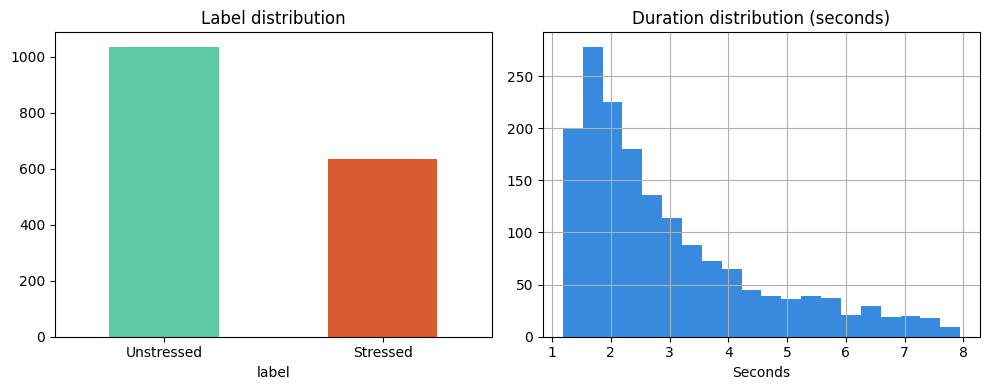


Final dataset stats:
Total samples  : 1670
Mean duration  : 2.97s
language  label
bodo      0         635
          1        1035
dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import os

# Adjust subplot creation for 1 row, 2 columns (removing the 'source' plot)
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # Changed from (1,3) to (1,2) and figsize adjusted

# Label distribution
movie_df['label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#5DCAA5','#D85A30'],
    title='Label distribution')
axes[0].set_xticklabels(['Unstressed', 'Stressed'], rotation=0)

# Duration distribution
durations = []
for fpath in movie_df['filename']:
    try:
        y, sr = librosa.load(fpath, sr=16000)
        durations.append(librosa.get_duration(y=y, sr=sr))
    except:
        durations.append(0)

movie_df['duration'] = durations
# The duration plot is now at axes[1] instead of axes[2]
movie_df['duration'].hist(ax=axes[1], bins=20, color='#378ADD')
axes[1].set_title('Duration distribution (seconds)')
axes[1].set_xlabel('Seconds')

plt.tight_layout()

# Ensure the results directory exists before saving
results_path = f"{BASE_PATH}/results"
os.makedirs(results_path, exist_ok=True)

plt.savefig(f"{results_path}/dataset_summary.png", dpi=150)
plt.show()

print(f"\nFinal dataset stats:")
print(f"Total samples  : {len(movie_df)}")
print(f"Mean duration  : {movie_df['duration'].mean():.2f}s")
print(movie_df.groupby(['language','label']).size())

In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2Processor

MODEL_NAME = "facebook/wav2vec2-base"
DEVICE     = "cuda"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
model     = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels        = 2,           # adjust to your number of stress classes
    problem_type      = "single_label_classification",
    ignore_mismatched_sizes = True
)

model.freeze_feature_encoder()       # freeze CNN, only fine-tune transformer layers

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch
from torch.utils.data import Dataset
import librosa
import numpy as np
import pandas as pd

class StressDataset(Dataset):
    def __init__(self, dataframe, processor, max_length=16000*6):
        self.df         = dataframe.reset_index(drop=True)
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y, sr = librosa.load(row['filename'], sr=16000)

        # Pad or truncate to max_length
        if len(y) > self.max_length:
            y = y[:self.max_length]
        else:
            y = np.pad(y, (0, self.max_length - len(y)))

        inputs = self.processor(
            y,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        return {
            "input_values" : inputs.input_values.squeeze(),
            "labels"       : torch.tensor(row['label'], dtype=torch.long)
        }

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(CSV_PATH) # Changed path to use the correct variable
df['stratify_key'] = df['language'] + "_" + df['label'].astype(str)

train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df['stratify_key'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['stratify_key'],
    random_state=42
)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")
print(f"\nTrain label dist:\n{train_df['label'].value_counts()}")

train_dataset = StressDataset(train_df, processor)
val_dataset   = StressDataset(val_df,   processor)
test_dataset  = StressDataset(test_df,  processor)

Train : 1169
Val   : 250
Test  : 251

Train label dist:
label
1    724
0    445
Name: count, dtype: int64


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='macro')
    f1_per_class = f1_score(labels, predictions, average=None)
    return {
        "accuracy"    : round(acc, 4),
        "f1_macro"    : round(f1, 4),
        "f1_class_0"  : round(f1_per_class[0], 4),
        "f1_class_1"  : round(f1_per_class[1], 4),
    }

In [ ]:
from transformers import TrainingArguments, Trainer

total_steps = (len(train_dataset) / 8) * 50  # total training steps

training_args = TrainingArguments(
    output_dir                  = "/content/stress_model",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    logging_strategy            = "epoch",
    num_train_epochs            = 50,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate               = 3e-5,          # ← lowered: wav2vec2-base is pretrained, needs gentler LR
    warmup_steps                = int(0.1 * total_steps),  # ← fixed: was computing wrong (15 was hardcoded)
    weight_decay                = 0.01,
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    fp16                        = True,
    report_to                   = "none",
    save_total_limit            = 2,
    dataloader_num_workers      = 2,             # ← speeds up data loading in Colab
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print("Starting training...")
trainer.train()

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
